# 02 - Training & Loss Functions

**Goal:** Understand how a neural network LEARNS its weights.

---

## The Training Loop

Training is surprisingly simple conceptually:

```
1. Forward pass: Feed input, get prediction
2. Calculate loss: How wrong is the prediction?
3. Backward pass: Calculate gradients (which direction to adjust weights)
4. Update weights: Nudge weights to reduce loss
5. Repeat thousands/millions of times
```

That's it. The entire field of deep learning is variations on this loop.

## Loss Function: Measuring "Wrongness"

The **loss function** (or cost function) measures how far the prediction is from the truth.

**For classification (e.g., "is this digit a 5?"):**
- Cross-Entropy Loss: Measures probability distribution difference

**For regression (e.g., "what's the house price?"):**
- Mean Squared Error (MSE): Average of squared differences

**For segmentation (your use case!):**
- Dice Loss: Measures overlap between predicted mask and ground truth
- Cross-Entropy per pixel: Classification at each pixel

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simple example: predicting a number
# Ground truth: 5.0
# Our prediction: 3.0

truth = 5.0
prediction = 3.0

# Mean Squared Error
mse_loss = (truth - prediction) ** 2
print(f"Truth: {truth}, Prediction: {prediction}")
print(f"MSE Loss: {mse_loss}")

# Better prediction
better_prediction = 4.5
better_mse_loss = (truth - better_prediction) ** 2
print(f"\nBetter prediction: {better_prediction}")
print(f"Better MSE Loss: {better_mse_loss} (lower = better)")

Truth: 5.0, Prediction: 3.0
MSE Loss: 4.0

Better prediction: 4.5
Better MSE Loss: 0.25 (lower = better)


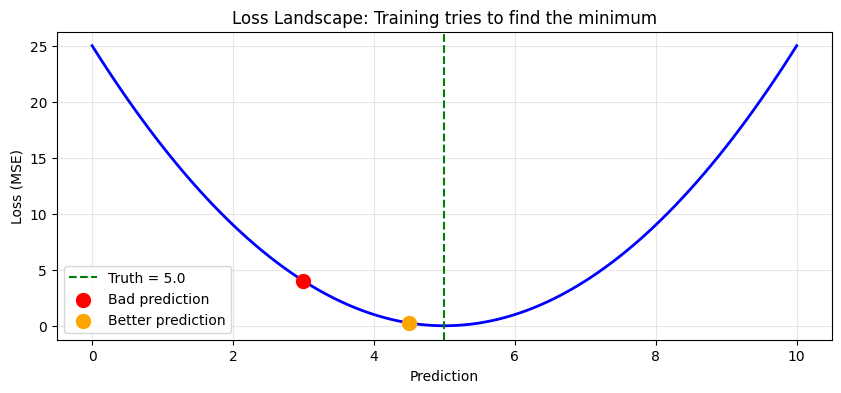

Training = moving down this curve toward the minimum (where prediction = truth)


In [7]:
# Visualize: Loss landscape for a simple case
# If truth = 5, what does loss look like for different predictions?

truth = 5.0
predictions = np.linspace(0, 10, 100)
losses = (truth - predictions) ** 2

plt.figure(figsize=(10, 4))
plt.plot(predictions, losses, 'b-', linewidth=2)
plt.axvline(x=truth, color='g', linestyle='--', label=f'Truth = {truth}')
plt.scatter([3.0], [(truth - 3.0)**2], color='r', s=100, zorder=5, label='Bad prediction')
plt.scatter([4.5], [(truth - 4.5)**2], color='orange', s=100, zorder=5, label='Better prediction')
plt.xlabel('Prediction')
plt.ylabel('Loss (MSE)')
plt.title('Loss Landscape: Training tries to find the minimum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Training = moving down this curve toward the minimum (where prediction = truth)")

## Backpropagation: Finding the Direction

**Gradient** = the slope of the loss with respect to each weight.

- If gradient is positive: increasing the weight increases the loss (bad) → decrease the weight
- If gradient is negative: increasing the weight decreases the loss (good) → increase the weight

**Backpropagation** calculates these gradients efficiently using the chain rule of calculus.

You don't need to implement this - PyTorch does it automatically with `loss.backward()`.

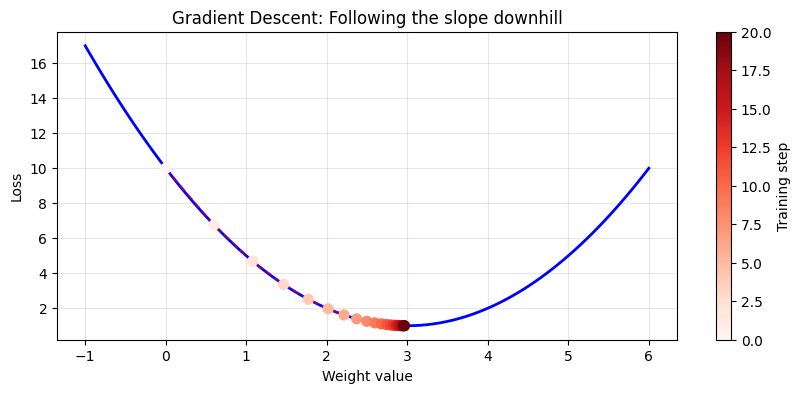

Started at weight = 0.0, loss = 10.00
Ended at weight = 2.97, loss = 1.00
Optimal weight = 3.0


In [8]:
# Simplified gradient descent visualization
# Imagine we have ONE weight to optimize

def loss_function(weight):
    """Fake loss function - in reality this is complex"""
    return (weight - 3.0) ** 2 + 1  # Minimum at weight = 3.0

def gradient(weight):
    """Derivative of loss with respect to weight"""
    return 2 * (weight - 3.0)

# Training simulation
weight = 0.0  # Start with random weight
learning_rate = 0.1  # How big of a step to take
history = [(weight, loss_function(weight))]

for step in range(20):
    grad = gradient(weight)
    weight = weight - learning_rate * grad  # Update: move opposite to gradient
    history.append((weight, loss_function(weight)))

# Plot the journey
weights = np.linspace(-1, 6, 100)
losses = [loss_function(w) for w in weights]

plt.figure(figsize=(10, 4))
plt.plot(weights, losses, 'b-', linewidth=2, label='Loss landscape')

# Plot training steps
hist_weights, hist_losses = zip(*history)
plt.scatter(hist_weights, hist_losses, c=range(len(history)), cmap='Reds', s=50, zorder=5)
plt.plot(hist_weights, hist_losses, 'r--', alpha=0.5)

plt.xlabel('Weight value')
plt.ylabel('Loss')
plt.title('Gradient Descent: Following the slope downhill')
plt.colorbar(label='Training step')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Started at weight = 0.0, loss = {loss_function(0.0):.2f}")
print(f"Ended at weight = {weight:.2f}, loss = {loss_function(weight):.2f}")
print(f"Optimal weight = 3.0")

## The Complete Training Loop (Pseudocode)

```python
model = create_neural_network()
optimizer = SGD(model.parameters(), learning_rate=0.01)

for epoch in range(100):  # Epoch = one pass through entire dataset
    for batch in dataloader:  # Batch = subset of data
        images, labels = batch
        
        # 1. Forward pass
        predictions = model(images)
        
        # 2. Calculate loss
        loss = loss_function(predictions, labels)
        
        # 3. Backward pass (calculate gradients)
        loss.backward()  # PyTorch magic
        
        # 4. Update weights
        optimizer.step()  # Applies gradients to weights
        optimizer.zero_grad()  # Reset gradients for next batch
    
    print(f"Epoch {epoch}, Loss: {loss.item()}")

# Save learned weights
torch.save(model.state_dict(), 'best_model.pth')
```

## Key Terms

| Term | Meaning |
|------|--------|
| **Epoch** | One complete pass through all training data |
| **Batch** | Subset of data processed together (e.g., 32 images) |
| **Learning rate** | How big of a step to take when updating weights |
| **Gradient** | Direction of steepest increase in loss |
| **Backpropagation** | Algorithm to calculate gradients efficiently |
| **Optimizer** | Algorithm that updates weights (SGD, Adam, etc.) |
| **Loss** | Single number measuring how wrong the model is |
| **Convergence** | When loss stops decreasing (training is "done") |

## Why Batches? Why Not One Image at a Time?

1. **GPU efficiency**: GPUs are fast at parallel computation. Processing 32 images at once is almost as fast as 1.

2. **Stable gradients**: Averaging gradients over a batch reduces noise.

3. **Memory trade-off**: Larger batch = more stable but needs more GPU memory.

Your production config shows this:
```yaml
testing:
  inference:
    simultaneous_patch: 4  # Process 4 patches at once
```

## Segmentation Loss (Your Use Case)

For image segmentation, we're classifying EVERY PIXEL.

**Dice Loss** is common for medical imaging:

```
Dice = 2 * |Prediction ∩ Truth| / (|Prediction| + |Truth|)
```

- Dice = 1.0 → Perfect overlap
- Dice = 0.0 → No overlap
- Dice Loss = 1 - Dice (so lower is better)

This handles class imbalance well (background pixels >> vertebrae pixels).

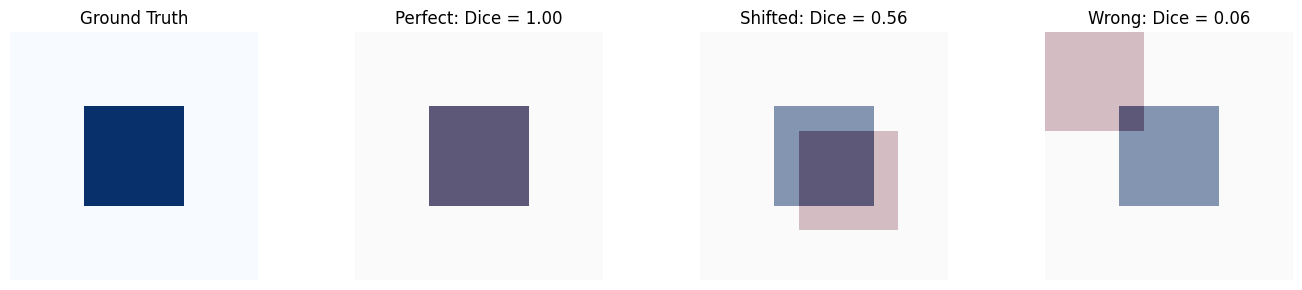

Blue = Ground truth, Red = Prediction, Purple = Overlap


In [9]:
# Dice coefficient visualization
def dice_coefficient(pred, truth):
    """Calculate Dice coefficient between two binary masks"""
    intersection = np.sum(pred & truth)
    return 2 * intersection / (np.sum(pred) + np.sum(truth) + 1e-8)

# Create example masks (simplified 2D)
truth = np.zeros((10, 10), dtype=bool)
truth[3:7, 3:7] = True  # Square in the middle

# Different predictions
perfect = truth.copy()
shifted = np.zeros((10, 10), dtype=bool)
shifted[4:8, 4:8] = True  # Shifted square
bad = np.zeros((10, 10), dtype=bool)
bad[0:4, 0:4] = True  # Completely wrong

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(truth, cmap='Blues')
axes[0].set_title('Ground Truth')

axes[1].imshow(perfect, cmap='Reds', alpha=0.5)
axes[1].imshow(truth, cmap='Blues', alpha=0.5)
axes[1].set_title(f'Perfect: Dice = {dice_coefficient(perfect, truth):.2f}')

axes[2].imshow(shifted, cmap='Reds', alpha=0.5)
axes[2].imshow(truth, cmap='Blues', alpha=0.5)
axes[2].set_title(f'Shifted: Dice = {dice_coefficient(shifted, truth):.2f}')

axes[3].imshow(bad, cmap='Reds', alpha=0.5)
axes[3].imshow(truth, cmap='Blues', alpha=0.5)
axes[3].set_title(f'Wrong: Dice = {dice_coefficient(bad, truth):.2f}')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Blue = Ground truth, Red = Prediction, Purple = Overlap")

## Training vs Inference

| | Training | Inference |
|---|----------|----------|
| **What happens** | Learn weights from data | Use learned weights to predict |
| **Gradients** | Calculated (backprop) | Not needed |
| **Data** | Training dataset | New unseen data |
| **Goal** | Minimize loss | Fast, accurate predictions |
| **GPU memory** | High (stores gradients) | Lower |
| **Your code** | You don't have this | `segmentation/` folder |

The ML team does training → produces `.pth` files → you load them for inference.

```python
# Inference mode (your production code)
model.eval()  # Disable dropout, batch norm in eval mode
with torch.no_grad():  # Don't calculate gradients
    prediction = model(image)
```

## Summary

1. **Loss function** measures how wrong the model is (lower = better)
2. **Gradients** tell us which direction to adjust weights
3. **Backpropagation** calculates gradients efficiently (PyTorch does this)
4. **Training loop**: forward → loss → backward → update, repeat
5. **Dice loss** is used for segmentation (measures overlap)

**Next:** Why GPUs? What makes them good for this?